# 12.3. 화학 결합의 정체

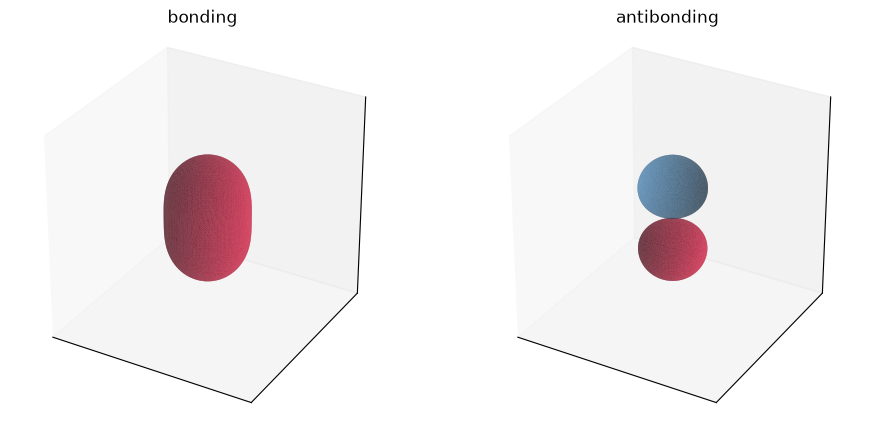

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from scipy.constants import physical_constants

a0 = physical_constants["Bohr radius"][0]


def R(n, l, r):
    rho = r / a0
    radial = {
        (1, 0): 2 * np.exp(-rho),
        (2, 0): (1 / (2 * np.sqrt(2))) * (2 - rho) * np.exp(-rho / 2),
        (2, 1): (1 / np.sqrt(24)) * rho * np.exp(-rho / 2),
        (3, 0): (2 / (81 * np.sqrt(3))) * (27 - 18 * rho + 2 * rho**2) * np.exp(-rho / 3),
        (3, 1): (4 / (81 * np.sqrt(6))) * (6 * rho - rho**2) * np.exp(-rho / 3),
        (3, 2): (4 / (81 * np.sqrt(30))) * rho**2 * np.exp(-rho / 3),
    }

    return a0 ** (-3 / 2) * radial[(n, l)]


def S(R):
    return np.exp(-R) * (1 + R + R**2 / 3)


def mo_grid(R_bohr, sign, l_box, N=100):
    R_ = R_bohr * a0
    g = np.linspace(-l_box, l_box, N)
    X, Y, Z = np.meshgrid(g, g, g, indexing="ij")

    rA = np.sqrt(X**2 + Y**2 + (Z + R_ / 2) ** 2) + 1e-12 * a0
    rB = np.sqrt(X**2 + Y**2 + (Z - R_ / 2) ** 2) + 1e-12 * a0

    norm = 1 / np.sqrt(2 * (1 + sign * S(R_bohr)))
    return g, norm * (R(1, 0, rA) + sign * R(1, 0, rB))


def draw(ax, psi, g, frac, title=""):
    level = np.abs(psi).max() * frac
    d = g[1] - g[0]
    for lv, col in [(level, "crimson"), (-level, "steelblue")]:
        if not psi.min() < lv < psi.max():
            continue
        v, f, _, _ = measure.marching_cubes(psi, lv, spacing=(d,) * 3)
        v = v + g[0]
        ax.plot_trisurf(v[:, 0] / a0, v[:, 1] / a0, f, v[:, 2] / a0, color=col, alpha=0.6, lw=0)
    L = g.max() / a0
    ax.set_xlim(-L, L)
    ax.set_ylim(-L, L)
    ax.set_zlim(-L, L)
    ax.set_box_aspect((1, 1, 1))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_title(title, fontsize=12)


R_e = 2.4935

fig = plt.figure(figsize=(11, 5))

for i, (sign, name) in enumerate([(+1, "bonding"), (-1, "antibonding")], 1):
    ax = fig.add_subplot(1, 2, i, projection="3d")
    g, psi = mo_grid(R_e, sign, 5 * a0)
    draw(ax, psi, g, frac=0.2, title=name)
plt.show()

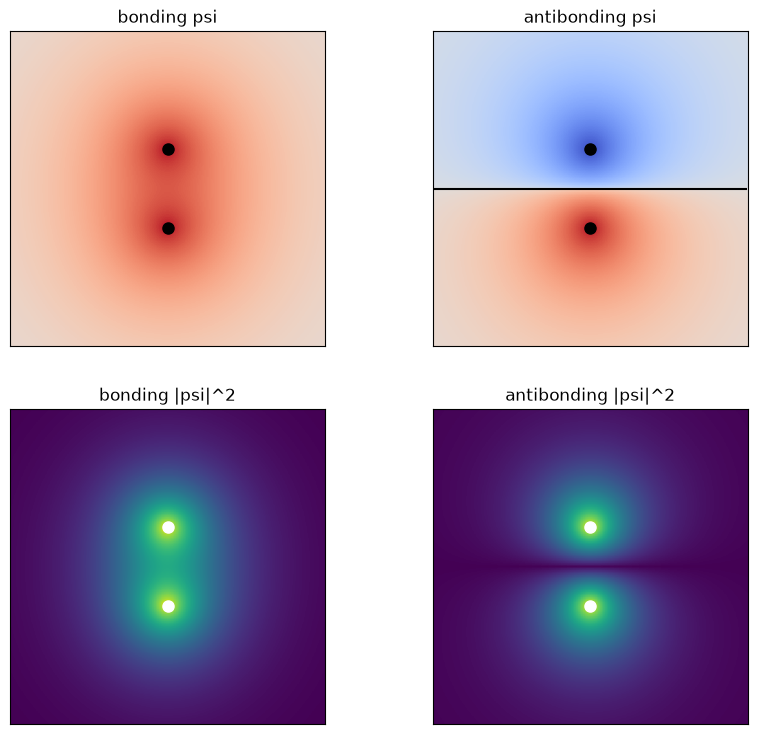

In [2]:
def mo_slice(R_bohr, sign, l_box, N=500):
    R_ = R_bohr * a0
    g = np.linspace(-l_box, l_box, N)
    X, Z = np.meshgrid(g, g)

    rA = np.sqrt(X**2 + (Z + R_ / 2) ** 2) + 1e-12 * a0
    rB = np.sqrt(X**2 + (Z - R_ / 2) ** 2) + 1e-12 * a0

    norm = 1 / np.sqrt(2 * (1 + sign * S(R_bohr)))
    return g, norm * (R(1, 0, rA) + sign * R(1, 0, rB))


fig, axes = plt.subplots(2, 2, figsize=(10, 9))

for j, (sign, name) in enumerate([(+1, "bonding"), (-1, "antibonding")]):
    g, psi = mo_slice(R_e, sign, 5 * a0)
    v = np.abs(psi).max()

    ax = axes[0, j]
    ax.pcolormesh(
        g / a0,
        g / a0,
        np.sign(psi) * np.abs(psi) ** 0.4,
        cmap="coolwarm",
        vmin=-(v**0.4),
        vmax=(v**0.4),
        shading="auto",
    )
    ax.contour(g / a0, g / a0, psi, levels=[0], colors="black", linewidths=1.5)
    ax.plot([0, 0], [-R_e / 2, R_e / 2], "o", ms=8, color="black")
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{name} psi", fontsize=12)

    ax = axes[1, j]
    ax.pcolormesh(g / a0, g / a0, (psi**2)**0.4, cmap="viridis", shading="auto")
    ax.plot([0, 0], [-R_e / 2, R_e / 2], "o", ms=8, color="white")
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{name} |psi|^2", fontsize=12)

plt.show()

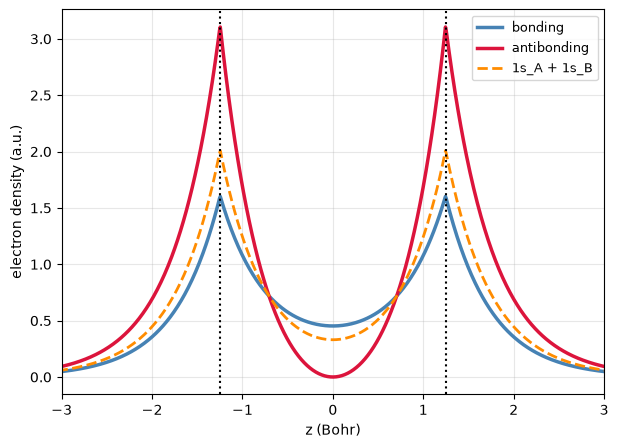

In [3]:
z = np.linspace(-4 * a0, 4 * a0, 1000)
R_ = R_e * a0
rA = np.abs(z + R_ / 2) + 1e-12 * a0
rB = np.abs(z - R_ / 2) + 1e-12 * a0
A, B = R(1, 0, rA), R(1, 0, rB)

fig, ax = plt.subplots(figsize=(7, 5))

for sign, name, col in [(+1, "bonding", "steelblue"), (-1, "antibonding", "crimson")]:
    mo = (A + sign * B) / np.sqrt(2 * (1 + sign * S(R_e)))
    ax.plot(z / a0, mo**2 * a0**3, lw=2.5, color=col, label=name)
ax.plot(z / a0, 0.5 * (A**2 + B**2) * a0**3, lw=2, ls="--", color="darkorange", label="1s_A + 1s_B")
for z in [-R_e / 2, R_e / 2]:
    ax.axvline(z, color="black", lw=1.5, ls=":")
ax.set_xlim(-3, 3)
ax.set_xlabel("z (Bohr)")
ax.set_ylabel("electron density (a.u.)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.show()

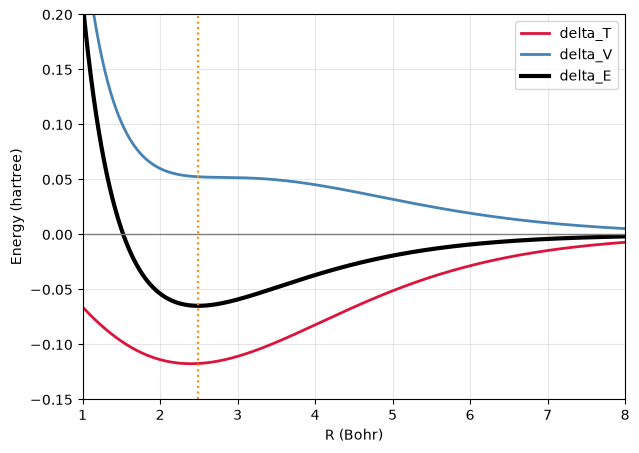

R = 2.49: dT = -0.1173, dV = 0.0525, dE = -0.0648


In [4]:
def J(R):
    return np.exp(-2 * R) * (1 + 1 / R) - 1 / R


def K(R):
    return -np.exp(-R) * (1 + R)


def energies(R):
    s, j, k = S(R), J(R), K(R)
    T = (1 - s - 2 * k) / (2 + 2 * s)
    V = (-1 + j + 2 * k) / (1 + s) + 1 / R
    return T, V


R = np.linspace(1, 8, 1000)
T, V = energies(R)
i = np.argmin(T + V)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(R, T - 0.5, lw=2, color="crimson", label="delta_T")
ax.plot(R, V + 1, lw=2, color="steelblue", label="delta_V")
ax.plot(R, T + V + 0.5, lw=3, color="black", label="delta_E")
ax.axhline(0, color="gray", lw=1)
ax.axvline(R[i], color="darkorange", ls=":", lw=1.5)
ax.set_xlim(1, 8)
ax.set_ylim(-0.15, 0.2)
ax.set_xlabel("R (Bohr)")
ax.set_ylabel("Energy (hartree)")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.show()

R_min = R[i]
T_min, V_min = energies(R_min)
print(f"R = {R_min:.2f}: dT = {T_min - 0.5:.4f}, dV = {V_min + 1:.4f}, dE = {T_min + V_min + 0.5:.4f}")

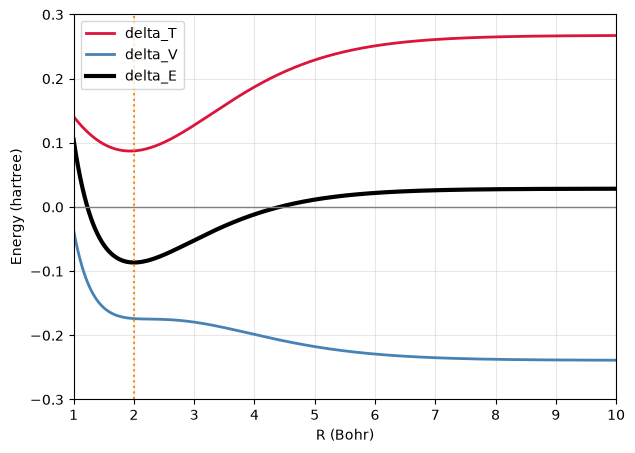

R = 2.00: dT = 0.0874, dV = -0.1739, dE = -0.0865


In [5]:
def energies_var(zeta, R):
    s, j, k = S(zeta * R), J(zeta * R), K(zeta * R)
    T = (1 - s - 2 * k) / (2 + 2 * s) * zeta**2
    V = (-1 + j + 2 * k) / (1 + s) * zeta + 1 / R 
    return T, V


R = np.linspace(1, 10, 2000)
zeta = 1.239
T, V = energies_var(zeta, R)
i = np.argmin(T + V)
R_min = R[i]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(R, T - 0.5, lw=2, color="crimson", label="delta_T")
ax.plot(R, V + 1, lw=2, color="steelblue", label="delta_V")
ax.plot(R, T + V + 0.5, lw=3, color="black", label="delta_E")
ax.axhline(0, color="gray", lw=1)
ax.axvline(R_min, color="darkorange", ls=":", lw=1.5)
ax.set_xlim(1, 10)
ax.set_ylim(-0.3, 0.3)
ax.set_xlabel("R (Bohr)")
ax.set_ylabel("Energy (hartree)")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.show()

T_min, V_min = energies_var(zeta, R_min)
print(f"R = {R_min:.2f}: dT = {T_min - 0.5:.4f}, dV = {V_min + 1:.4f}, dE = {T_min + V_min + 0.5:.4f}")